In [ ]:
# Cell 1 - Imports

import sys
import os
import importlib
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection
import model.valuation as valuation

In [ ]:
# Cell 2 - Define reload all function

def reload_all():
    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection)
    importlib.reload(valuation)

In [ ]:
# Cell 3 - Run reload all to ensure latest code is loaded

reload_all()

In [ ]:
# Cell 4 - Define assumptions and policy

assumptions = assumptions_module.Assumptions(interest_rate=0.03)

policy = policy_module.Policy(
    age=40,
    term=10,
    sum_assured=100000,
    premium=1000
)

In [ ]:
# Cell 5 - Debugging

df[["t", "pv_premium", "pv_claim", "pv_net", "cum_profit"]]

,t,pv_premium,pv_claim,pv_net,cum_profit
0,0,1000.000000,111.277046,888.722954,888.722954
1,1,969.793427,116.903734,852.889692,1741.612646
2,2,940.412029,122.803539,817.608490,2559.221136
3,3,911.829120,128.988123,782.840997,3342.062132
4,4,884.018678,135.469418,748.549260,4090.611392
5,5,856.955324,142.259594,714.695730,4805.307122
6,6,830.614299,149.371019,681.243280,5486.550402
7,7,804.971446,156.816218,648.155228,6134.705630
8,8,780.003188,164.607810,615.395378,6750.101008
9,9,755.686514,172.758446,582.928068,7333.029077


In [ ]:
# Cell 6 - Define results table

def build_results_table(result):
    df = pd.DataFrame(result["breakdown"])
    df["pv_net"] = df["pv_premium"] - df["pv_claim"]
    df["cum_profit"] = df["pv_net"].cumsum()
    return df

In [ ]:
# Cell 8 - Print results table

df = build_results_table(result)
df

,t,age,discount_factor,expected_premium,expected_claim,pv_premium,pv_claim,pv_net,cum_profit
0,0,40,1.000000,1000.000000,111.277046,1000.000000,111.277046,888.722954,888.722954
1,1,41,0.970874,998.887230,120.410846,969.793427,116.903734,852.889692,1741.612646
2,2,42,0.942596,997.683121,130.282274,940.412029,122.803539,817.608490,2559.221136
3,3,43,0.915142,996.380298,140.948805,911.829120,128.988123,782.840997,3342.062132
4,4,44,0.888487,994.970810,152.472024,884.018678,135.469418,748.549260,4090.611392
5,5,45,0.862609,993.446090,164.917859,856.955324,142.259594,714.695730,4805.307122
6,6,46,0.837484,991.796911,178.356809,830.614299,149.371019,681.243280,5486.550402
7,7,47,0.813092,990.013343,192.864168,804.971446,156.816218,648.155228,6134.705630
8,8,48,0.789409,988.084702,208.520248,780.003188,164.607810,615.395378,6750.101008
9,9,49,0.766417,985.999499,225.410588,755.686514,172.758446,582.928068,7333.029077


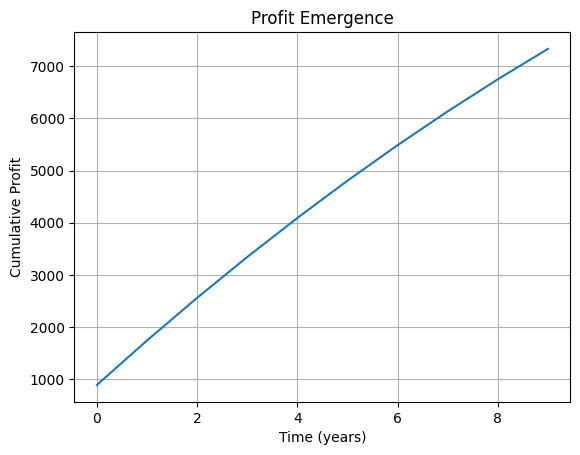

In [ ]:
# Cell 9 - Define and print profit emergence plot

plt.plot(df["t"], df["cum_profit"])
plt.xlabel("Time (years)")
plt.ylabel("Cumulative Profit")
plt.title("Profit Emergence")
plt.grid()

plt.show()